In [30]:
import pandas as pd
import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
data_root_dir = Path("/Users/the87/Downloads/IMC_GoTritons/round_4/data")

In [40]:
price_d1 = pd.read_csv(f"{data_root_dir}/prices_round_4_day_1.csv", sep=";")
price_d2 = pd.read_csv(f"{data_root_dir}/prices_round_4_day_2.csv", sep=";")
price_d3 = pd.read_csv(f"{data_root_dir}/prices_round_4_day_3.csv", sep=";")

In [44]:
price_d1["timestamp"] = price_d1["timestamp"] + 0 * 1_000_000
price_d2["timestamp"] = price_d2["timestamp"] + 1 * 1_000_000
price_d3["timestamp"] = price_d3["timestamp"] + 2 * 1_000_000
price_d1["day"] = 1
price_d2["day"] = 2
price_d3["day"] = 3

In [45]:
price_all = pd.concat([price_d1, price_d2, price_d3], ignore_index=True)

In [46]:
mid_price = price_all[['day', 'timestamp', 'product', 'mid_price']]

In [32]:
trade_d1 = pd.read_csv(os.path.join(data_root_dir, "trades_round_4_day_1.csv"), sep=";")
trade_d2 = pd.read_csv(os.path.join(data_root_dir, "trades_round_4_day_2.csv"), sep=";")
trade_d3 = pd.read_csv(os.path.join(data_root_dir, "trades_round_4_day_3.csv"), sep=";")

In [33]:
trade_d1['t_cont'] = 0 * 1_000_000 + trade_d1['timestamp']
trade_d2['t_cont'] = 1 * 1_000_000 + trade_d2['timestamp']
trade_d3['t_cont'] = 2 * 1_000_000 + trade_d3['timestamp']
trade_d1['day'] = 1; trade_d2['day'] = 2; trade_d3['day'] = 3

In [34]:
trade_all = pd.concat([trade_d1, trade_d2, trade_d3], ignore_index=True)

In [35]:
trade_all['buyer'].unique()

<StringArray>
['Mark 01', 'Mark 38', 'Mark 55', 'Mark 67', 'Mark 14', 'Mark 22', 'Mark 49']
Length: 7, dtype: str

In [36]:
m1_trades = trade_all[trade_all['seller'] == 'Mark 01']
m14_trades = trade_all[trade_all['seller'] == 'Mark 14']
m22_trades = trade_all[trade_all['seller'] == 'Mark 22']
m38_trades = trade_all[trade_all['seller'] == 'Mark 38']
m49_trades = trade_all[trade_all['seller'] == 'Mark 49']
m55_trades = trade_all[trade_all['seller'] == 'Mark 55']
m67_trades = trade_all[trade_all['seller'] == 'Mark 67']

In [38]:
def plot_trader(trader_id: str, save: bool = False) -> None:
    """
    Overlay a specific trader's buys/sells on the all-trades price plots.

    Parameters
    ----------
    trader_id : str   e.g. 'Mark 01'
    save      : bool  If True, saves figures as PNG in the current directory.
    """
    buys  = trade_all[trade_all['buyer']  == trader_id].copy(); buys['side']  = 'BUY'
    sells = trade_all[trade_all['seller'] == trader_id].copy(); sells['side'] = 'SELL'
    trader_trades = pd.concat([buys, sells], ignore_index=True)

    if trader_trades.empty:
        print(f"No trades found for '{trader_id}'")
        return

    side_style = {
        'BUY':  dict(marker='^', color='lime', edgecolors='darkgreen', s=80, zorder=5, label=f'{trader_id} BUY'),
        'SELL': dict(marker='v', color='red',  edgecolors='darkred',   s=80, zorder=5, label=f'{trader_id} SELL'),
    }

    day_colors = {1: 'steelblue', 2: 'darkorange', 3: 'green'}
    day_labels = {1: 'Day 1', 2: 'Day 2', 3: 'Day 3'}

    products     = sorted(trade_all['symbol'].unique())
    non_vouchers = [p for p in products if not p.startswith('VEV_')]
    vouchers     = [p for p in products if p.startswith('VEV_')]
    safe_id      = trader_id.replace(' ', '_')

    def _draw(ax, prod):
        sub = trade_all[trade_all['symbol'] == prod]
        for day, grp in sub.groupby('day'):
            ax.scatter(grp['t_cont'], grp['price'],
                       color=day_colors[day], s=4, alpha=0.2, label=day_labels[day])
        for side, style in side_style.items():
            t = trader_trades[(trader_trades['symbol'] == prod) & (trader_trades['side'] == side)]
            if not t.empty:
                ax.scatter(t['t_cont'], t['price'], linewidths=0.5, **style)
        for d in [1, 2]:
            ax.axvline(d * 1_000_000, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
        ax.set_title(prod, fontsize=10, fontweight='bold')
        ax.set_ylabel('Trade Price')
        ax.grid(alpha=0.3)
        handles, labels = ax.get_legend_handles_labels()
        seen = {}; [seen.setdefault(l, h) for h, l in zip(handles, labels)]
        ax.legend(seen.values(), seen.keys(), loc='upper right', fontsize=7, markerscale=1)

    # Non-vouchers
    fig, axes = plt.subplots(len(non_vouchers), 1, figsize=(16, 4 * len(non_vouchers)))
    if len(non_vouchers) == 1:
        axes = [axes]
    for ax, prod in zip(axes, non_vouchers):
        _draw(ax, prod)
    axes[-1].set_xlabel('Continuous Timestamp (day-1 × 1e6 + ts)')
    fig.suptitle(f"Round 4 — {trader_id} Trades (Non-Vouchers)", fontsize=13)
    plt.tight_layout()
    if save:
        fname = f"{safe_id}_non_vouchers.png"
        fig.savefig(fname, dpi=150, bbox_inches='tight')
        print(f"Saved: {fname}")
    plt.show()

    # Vouchers
    ncols = 3
    nrows = (len(vouchers) + ncols - 1) // ncols
    fig2, axes2 = plt.subplots(nrows, ncols, figsize=(18, 4 * nrows))
    axes2_flat  = axes2.flatten()
    for i, prod in enumerate(vouchers):
        _draw(axes2_flat[i], prod)
    for j in range(len(vouchers), len(axes2_flat)):
        axes2_flat[j].set_visible(False)
    axes2_flat[len(vouchers) - 1].set_xlabel('Continuous Timestamp')
    fig2.suptitle(f"Round 4 — {trader_id} Trades (VEV Vouchers)", fontsize=13)
    plt.tight_layout()
    if save:
        fname = f"{safe_id}_vouchers.png"
        fig2.savefig(fname, dpi=150, bbox_inches='tight')
        print(f"Saved: {fname}")
    plt.show()




Saved: Mark_01_non_vouchers.png


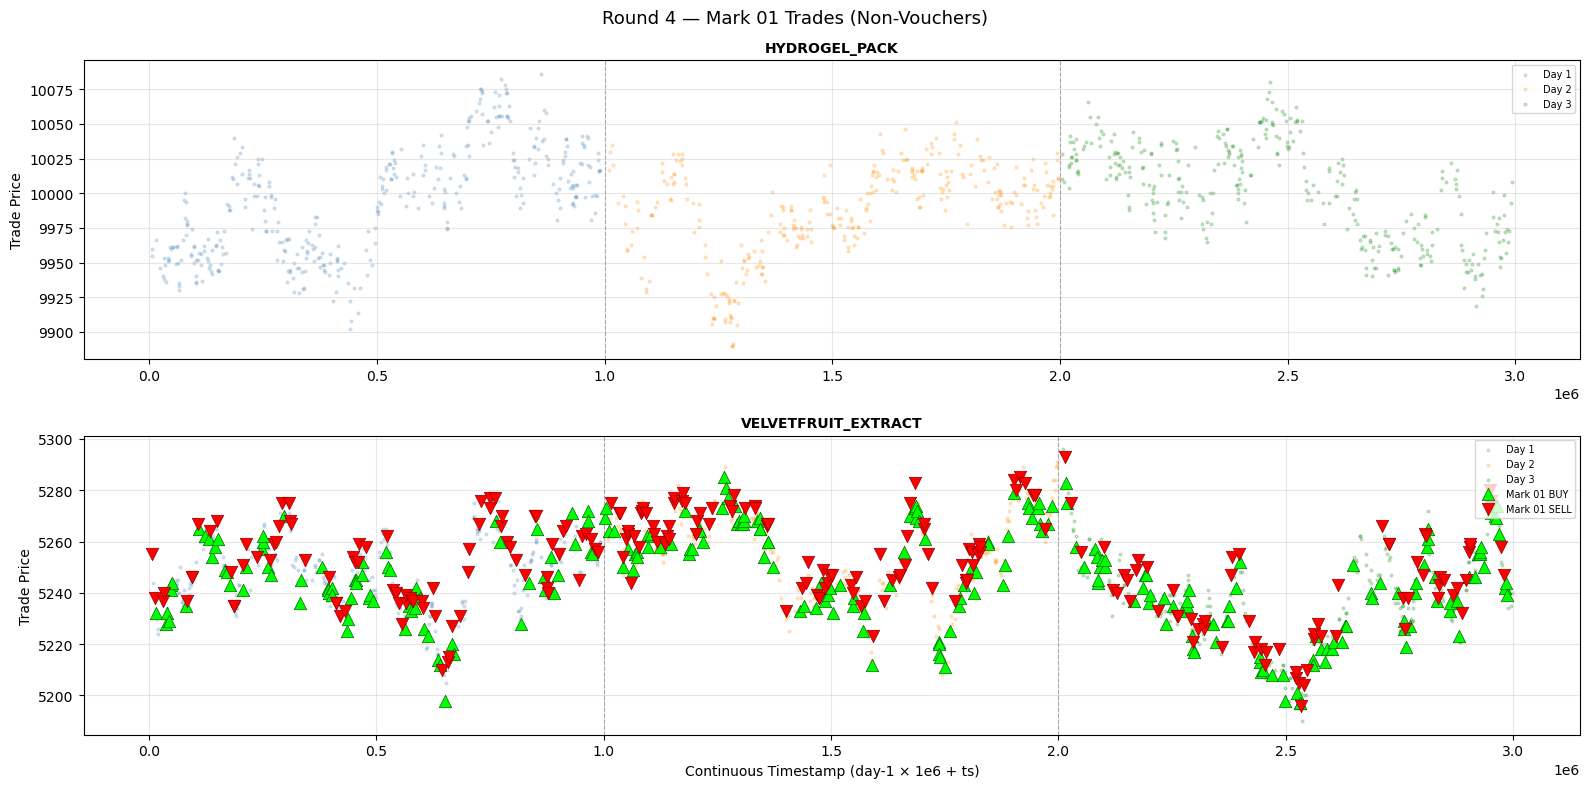

Saved: Mark_01_vouchers.png


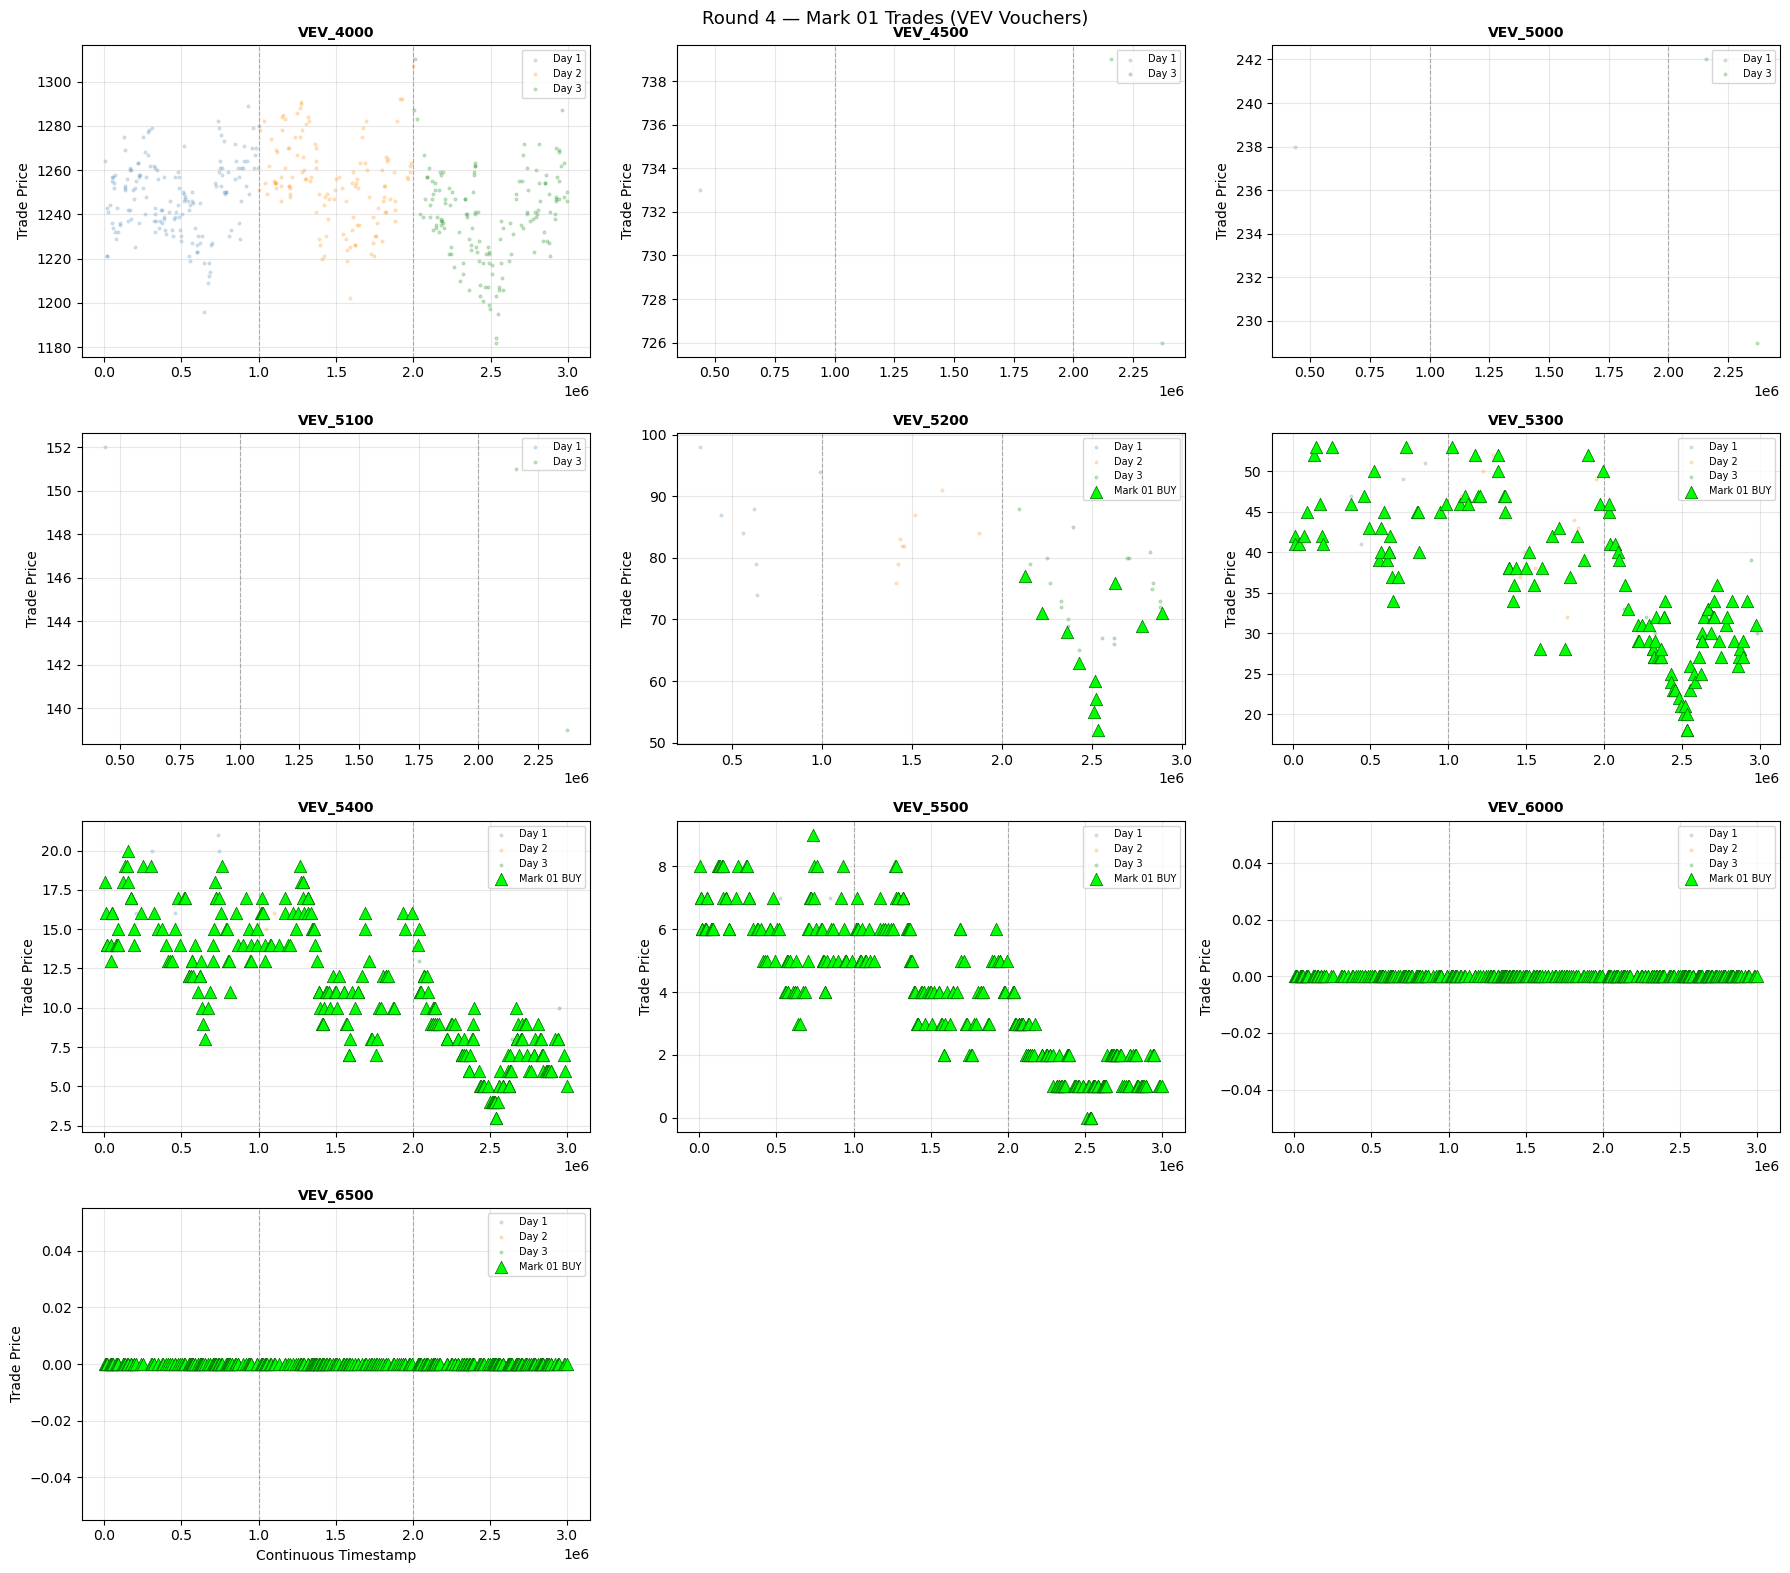

Saved: Mark_14_non_vouchers.png


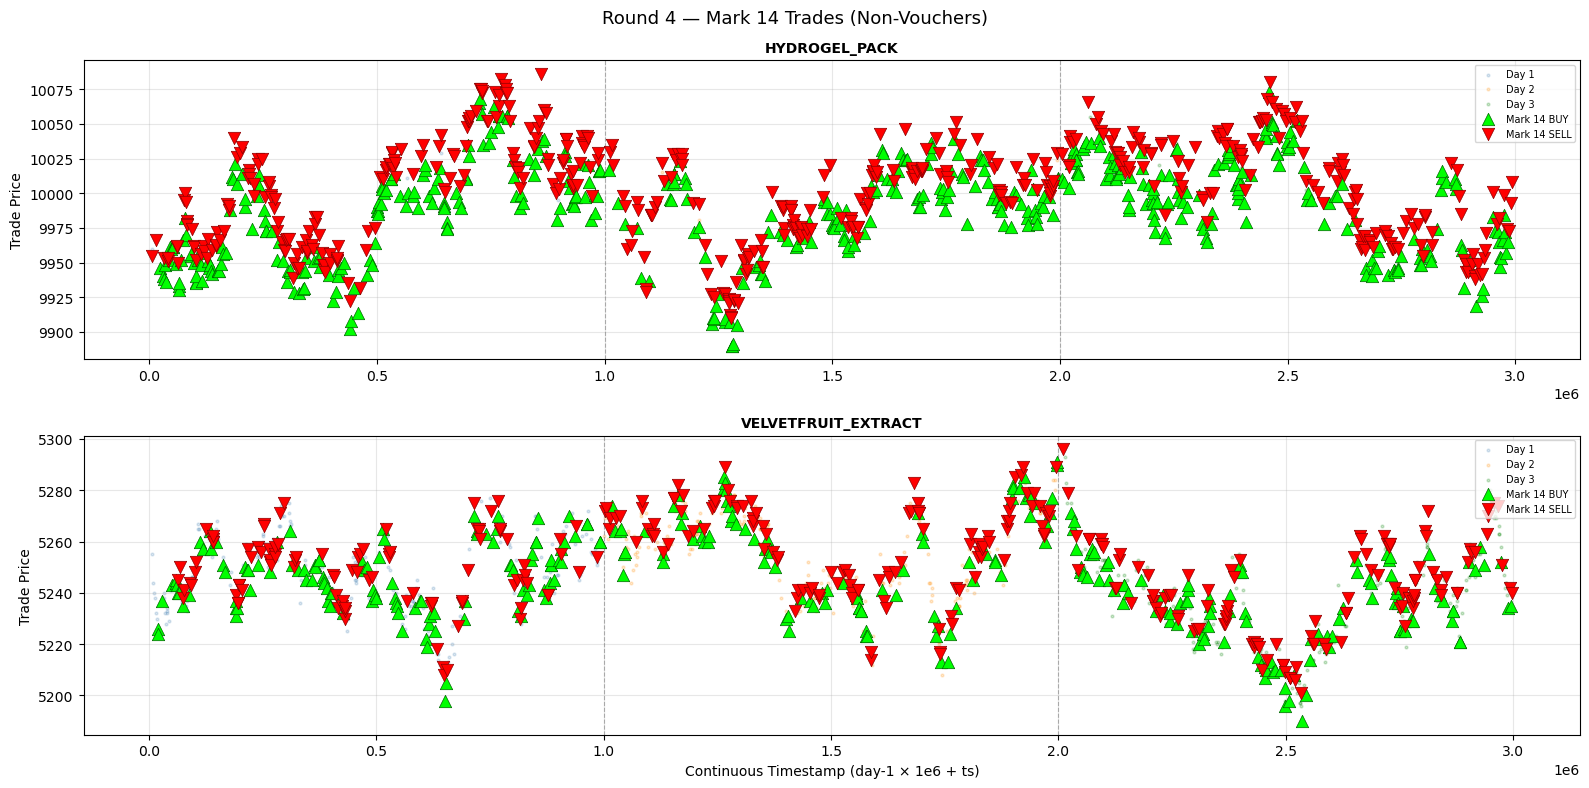

Saved: Mark_14_vouchers.png


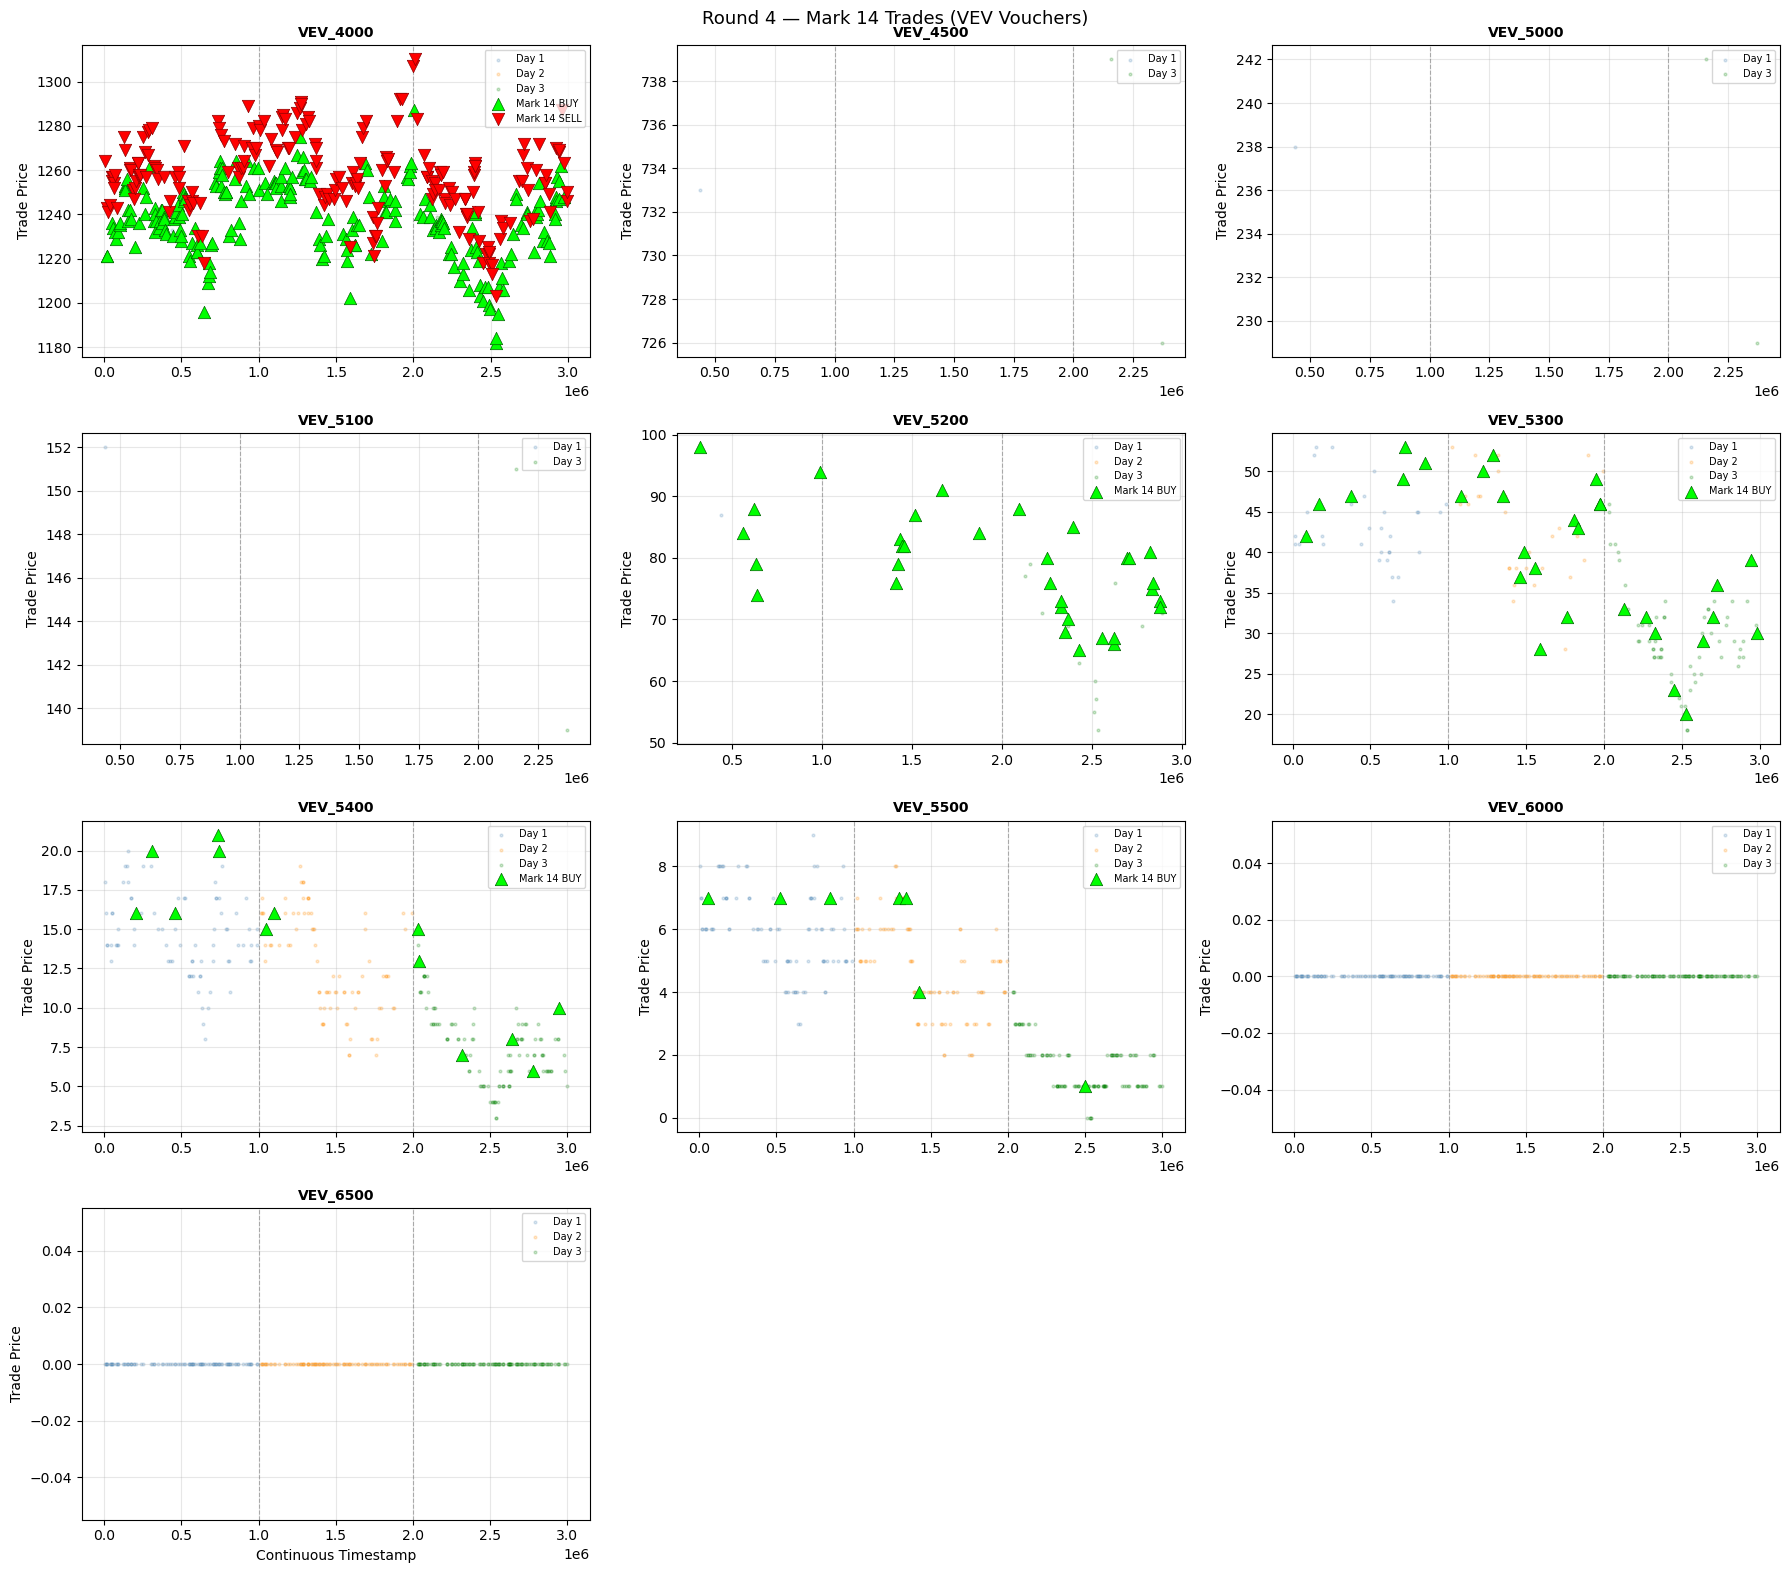

Saved: Mark_22_non_vouchers.png


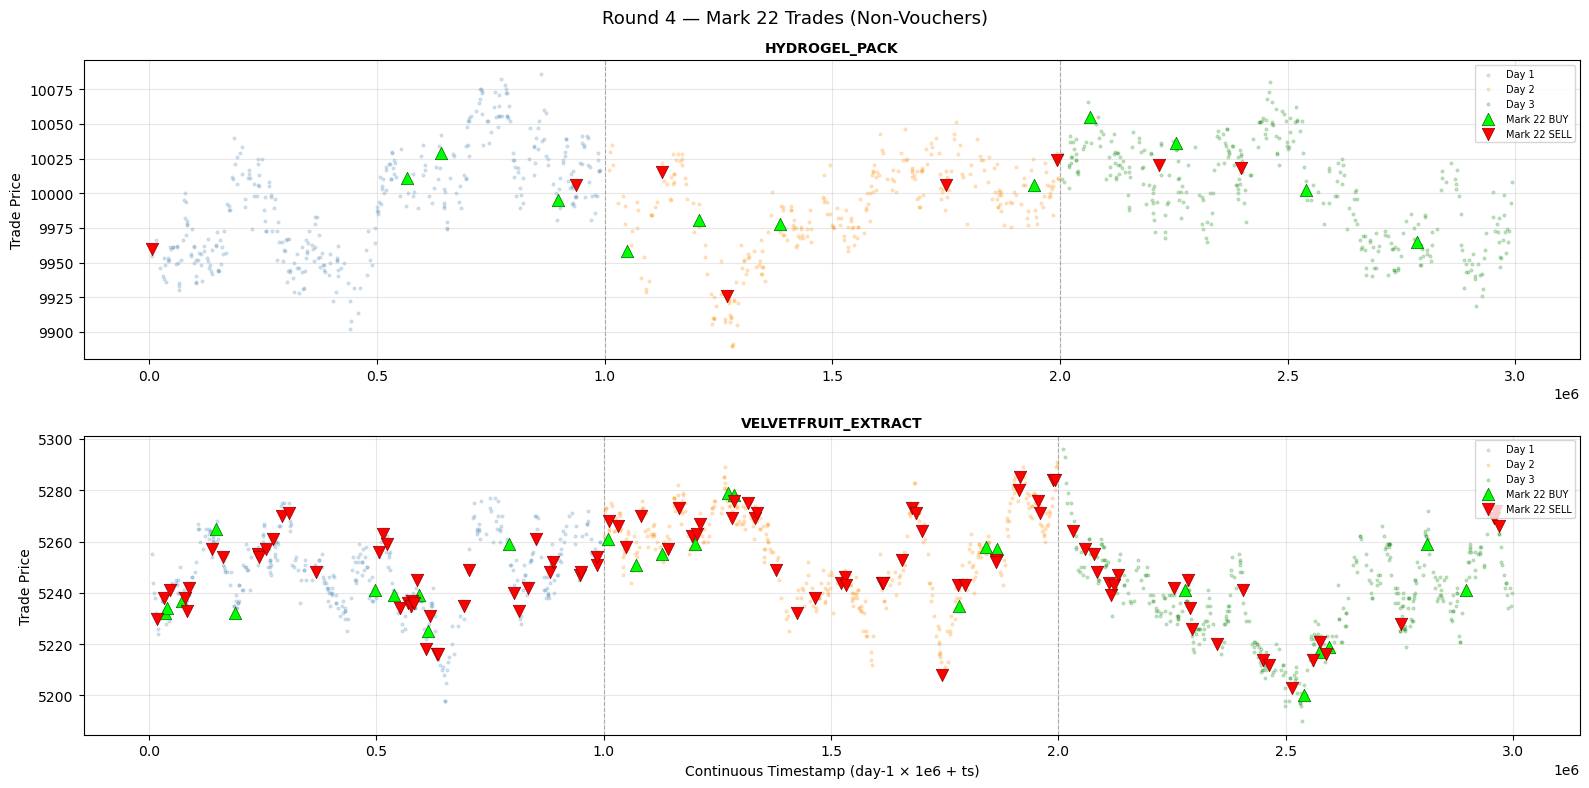

Saved: Mark_22_vouchers.png


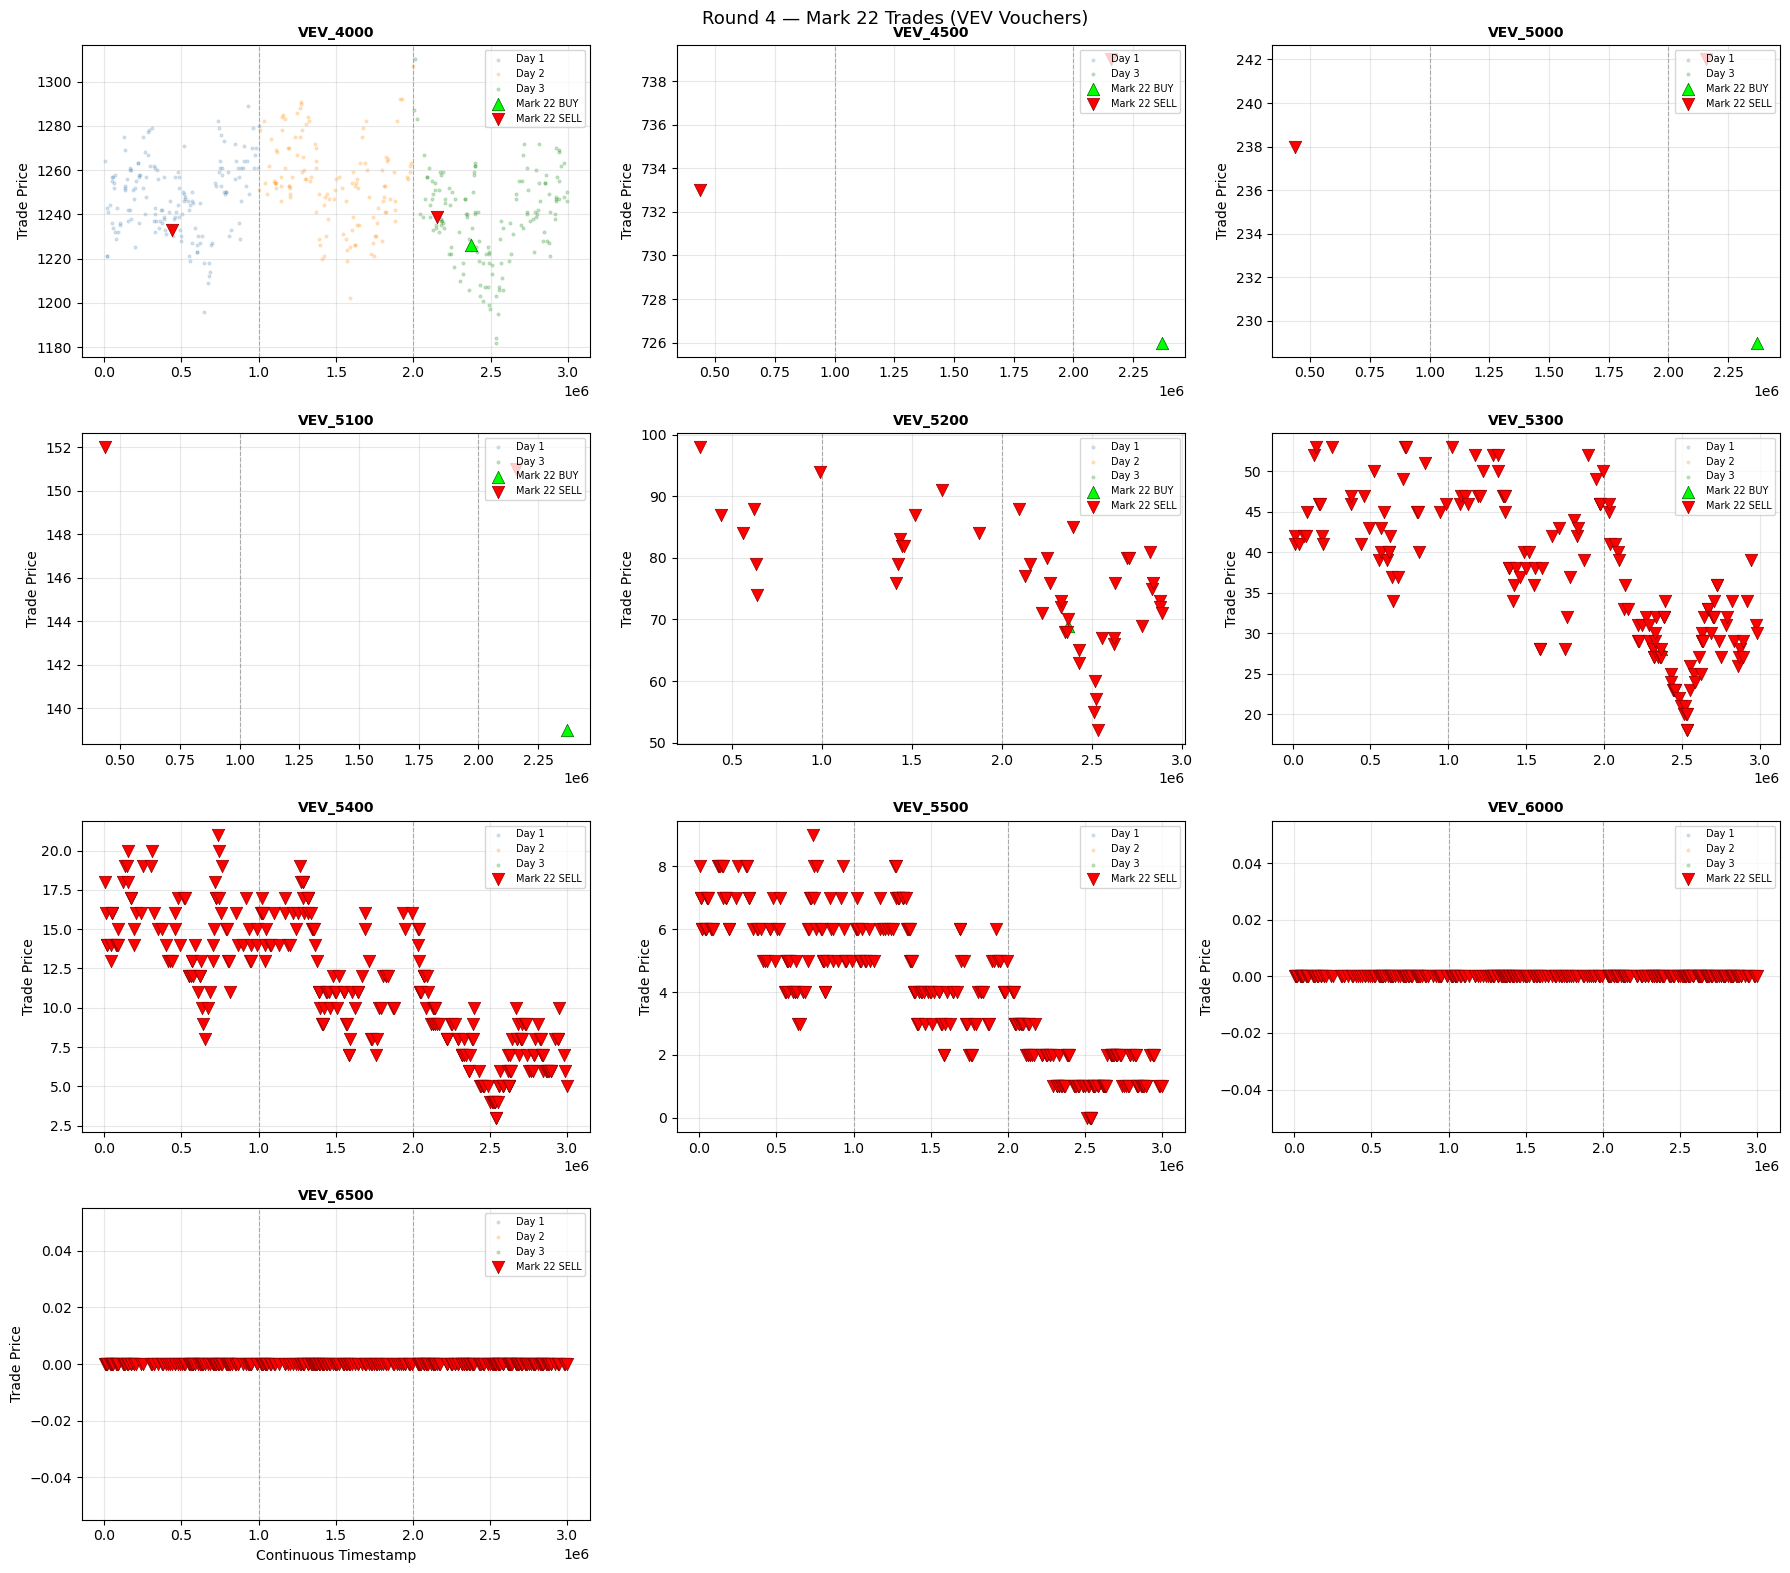

Saved: Mark_38_non_vouchers.png


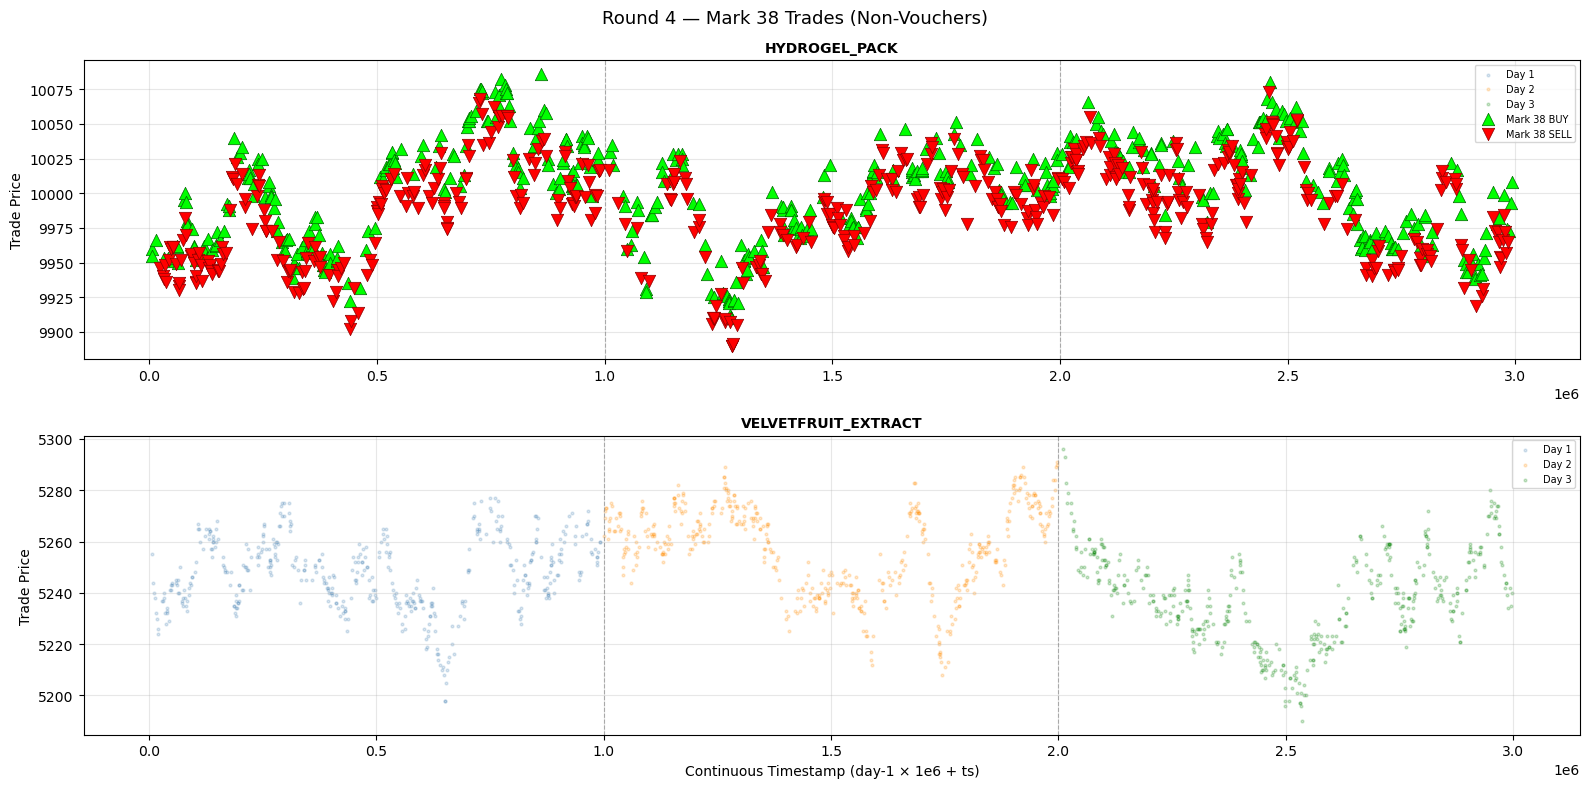

Saved: Mark_38_vouchers.png


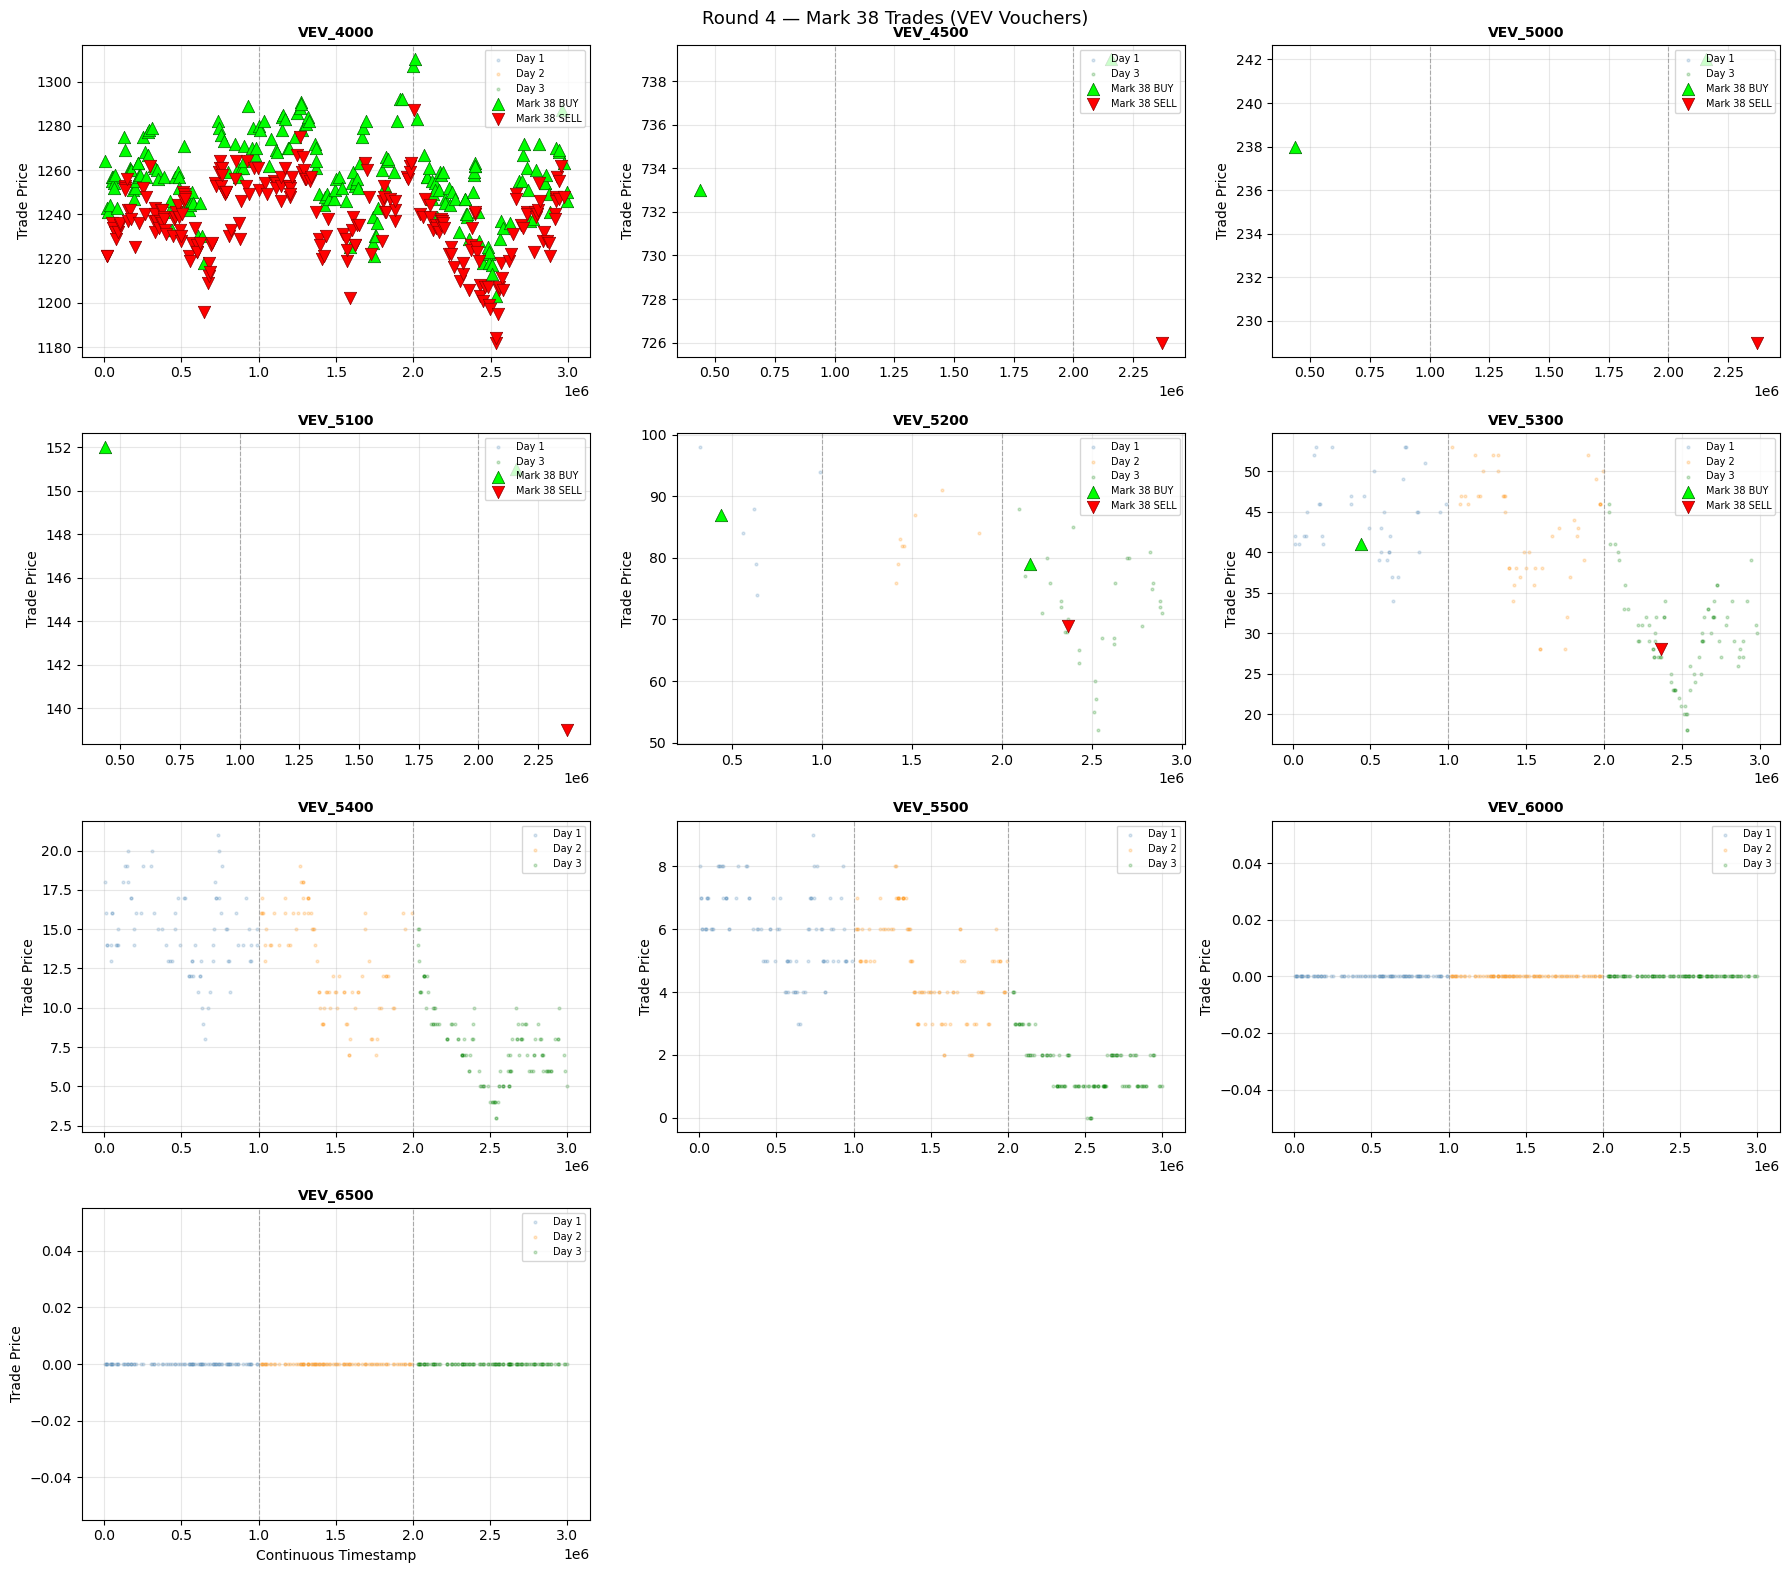

Saved: Mark_49_non_vouchers.png


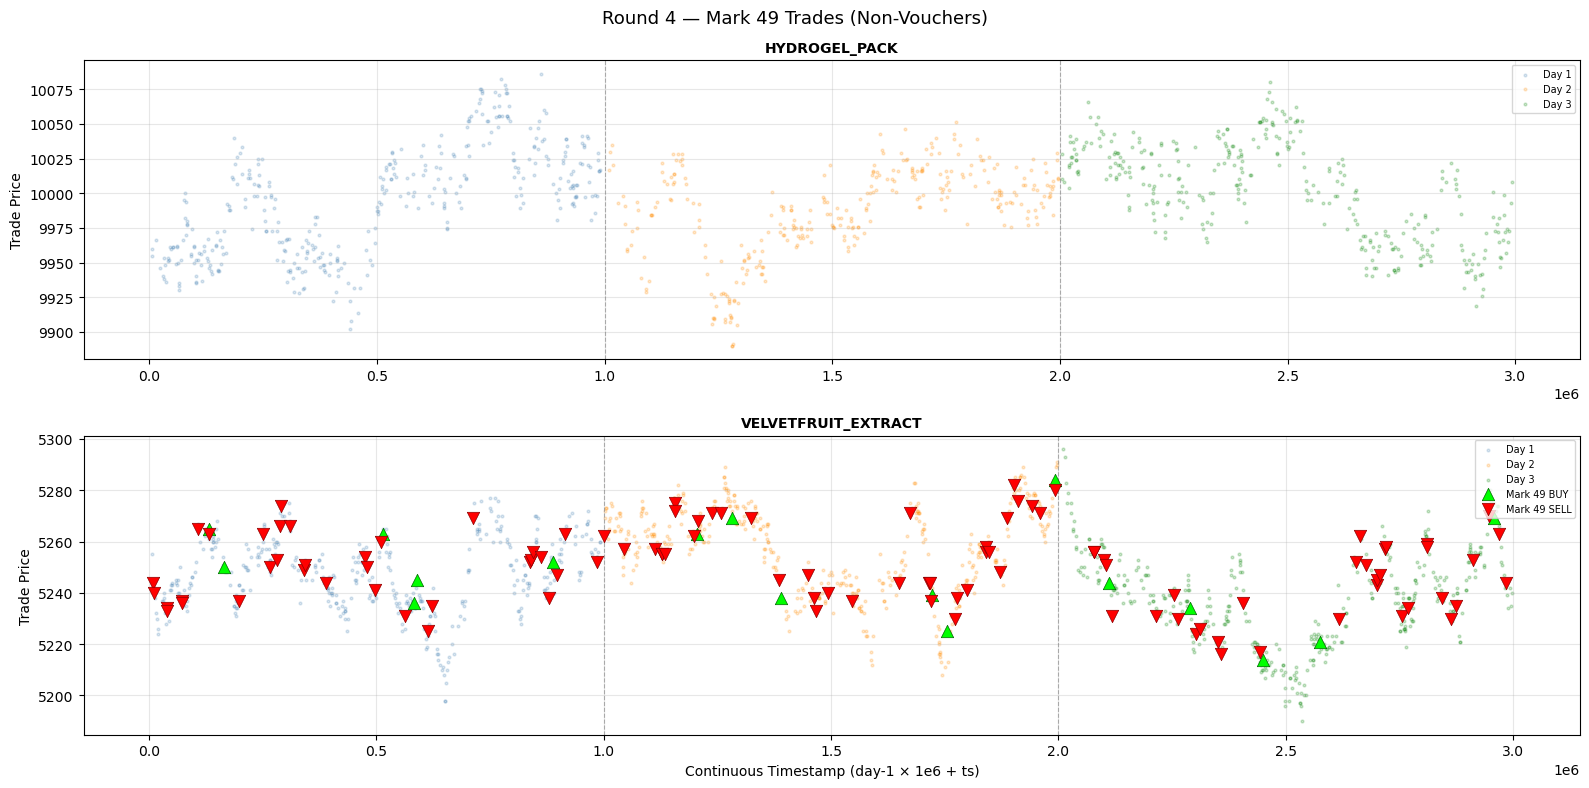

Saved: Mark_49_vouchers.png


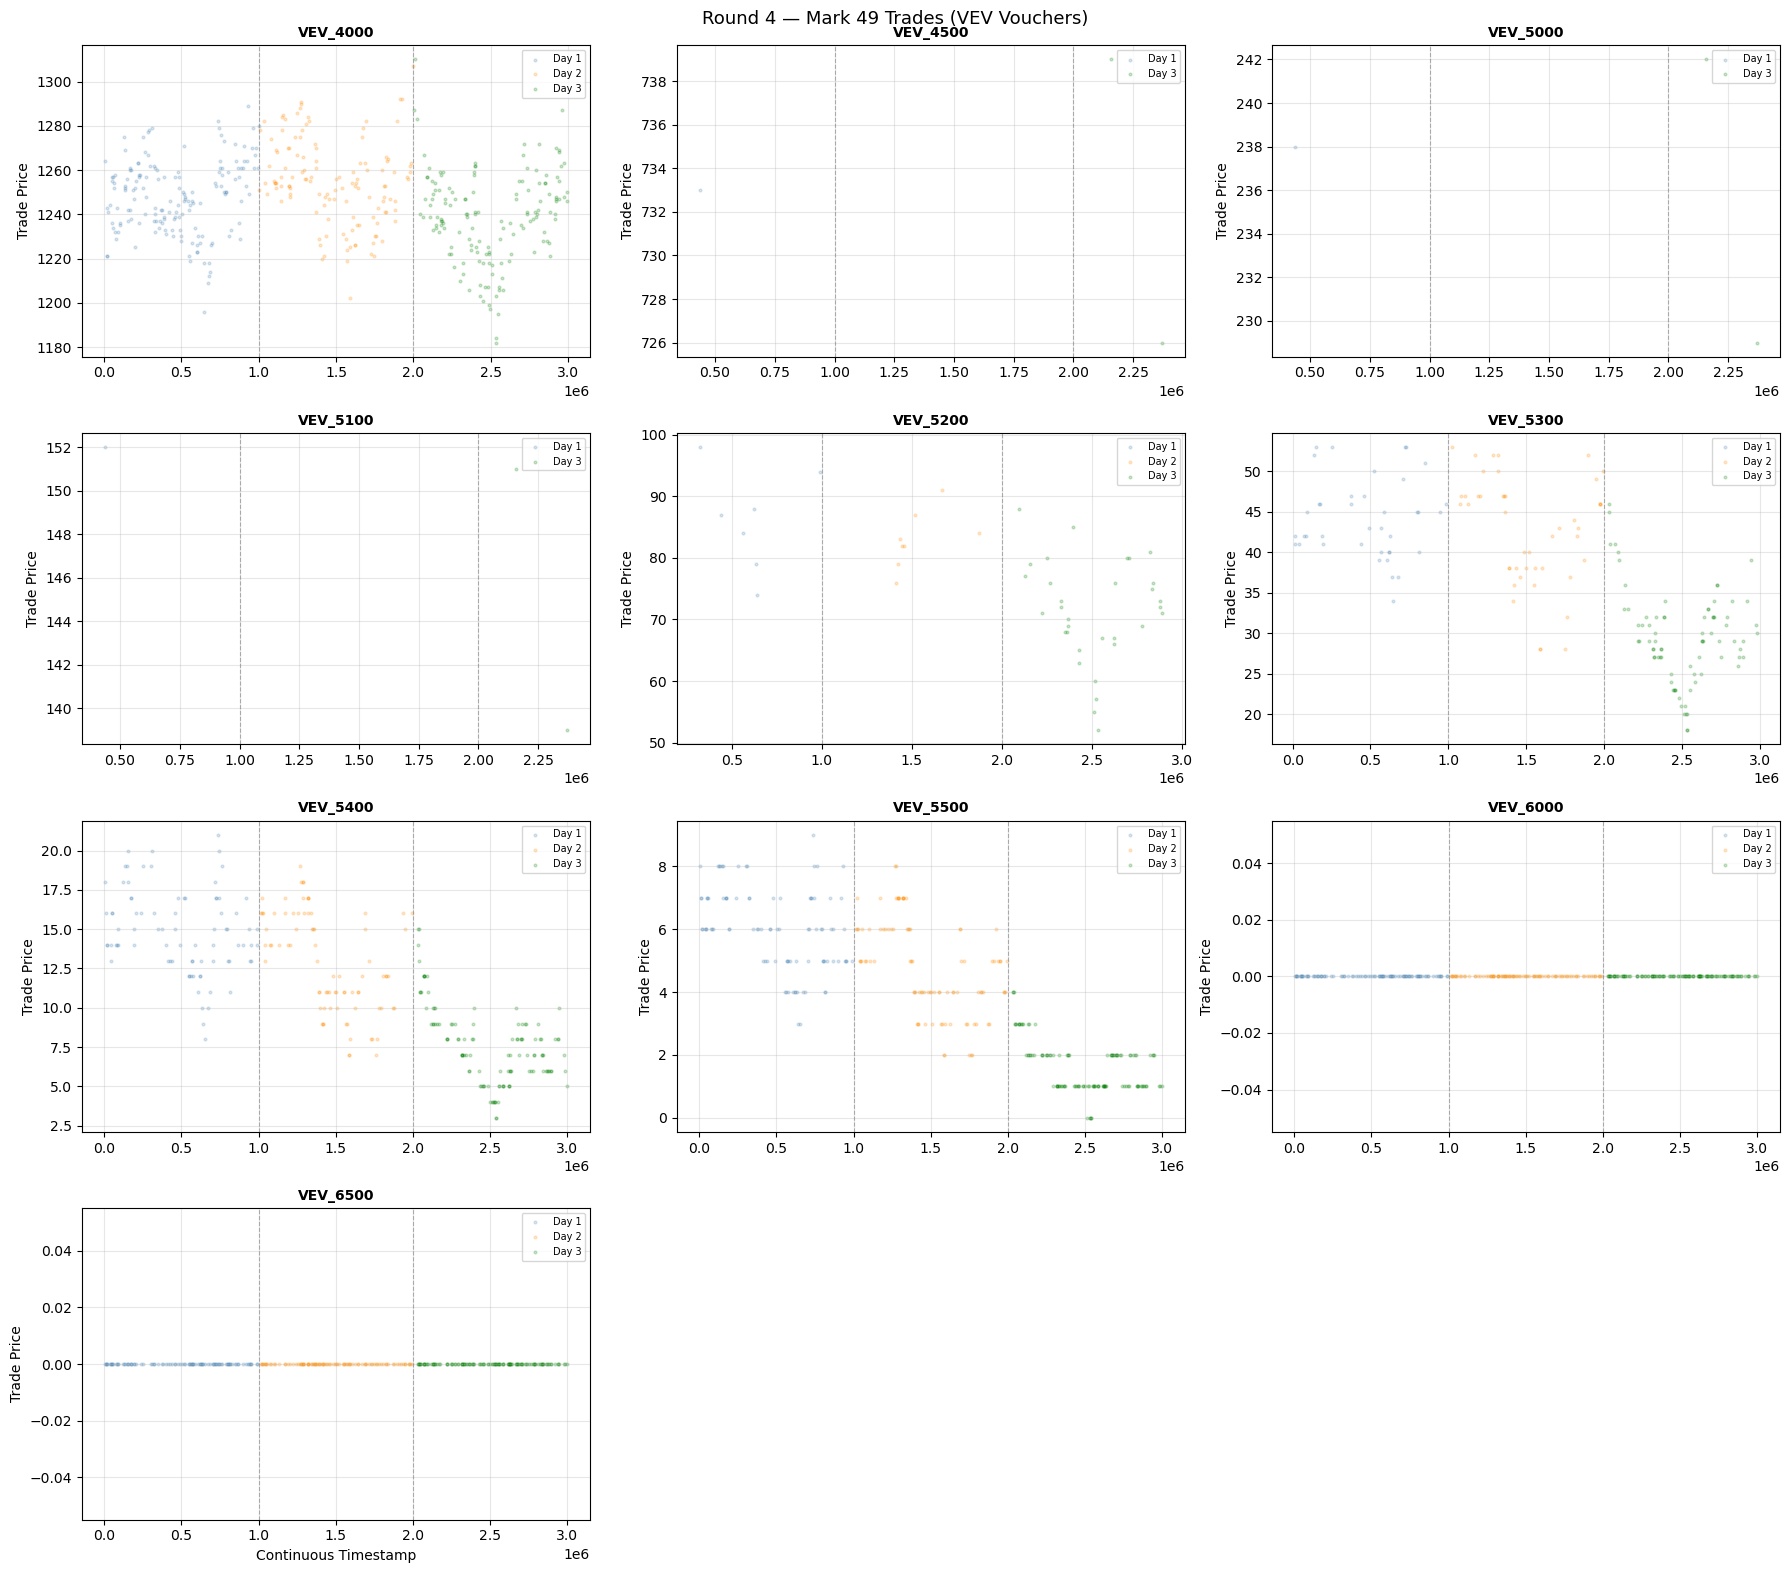

Saved: Mark_55_non_vouchers.png


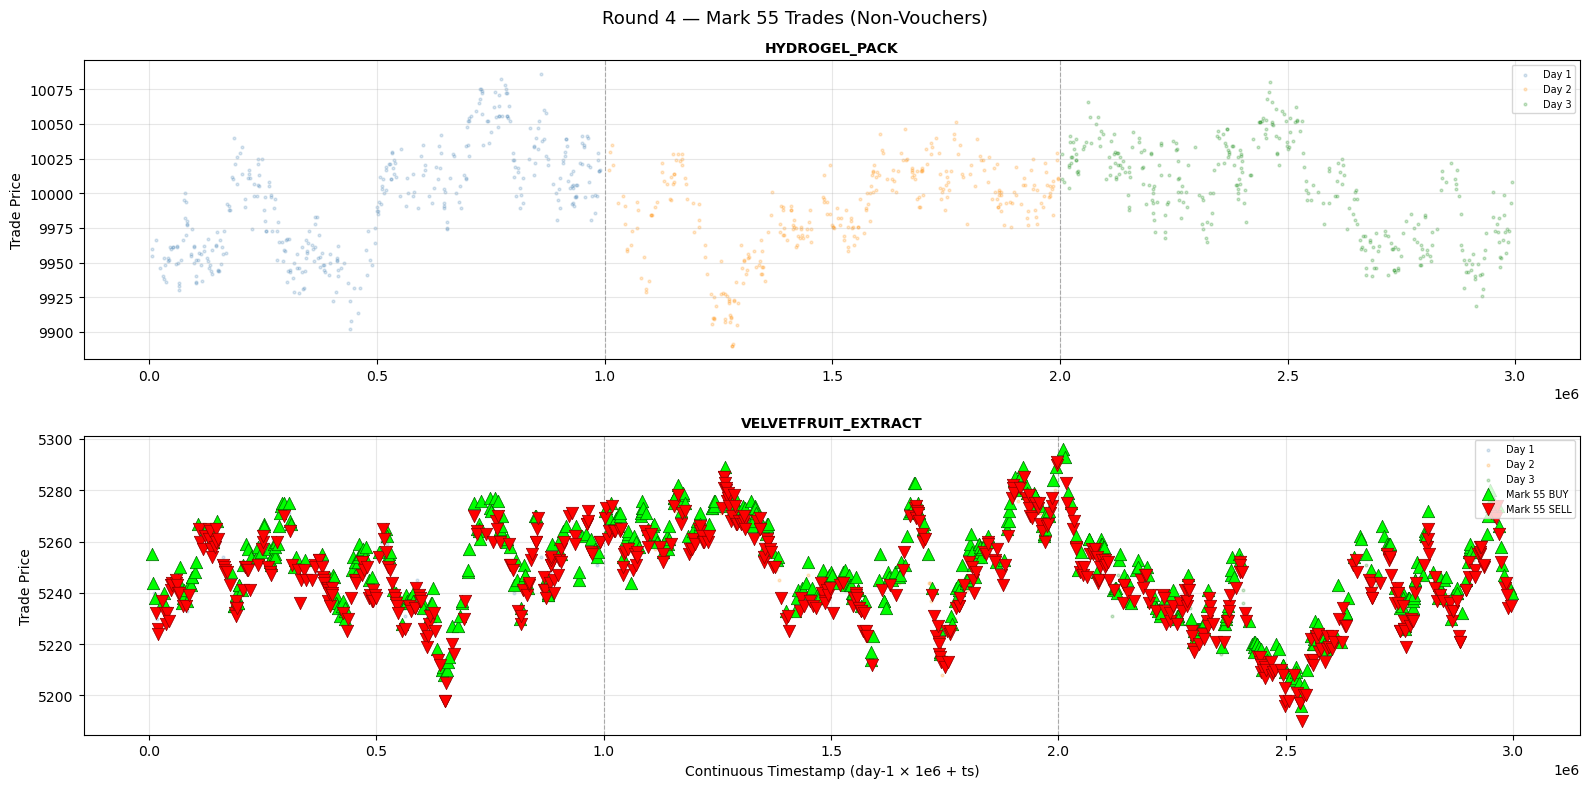

Saved: Mark_55_vouchers.png


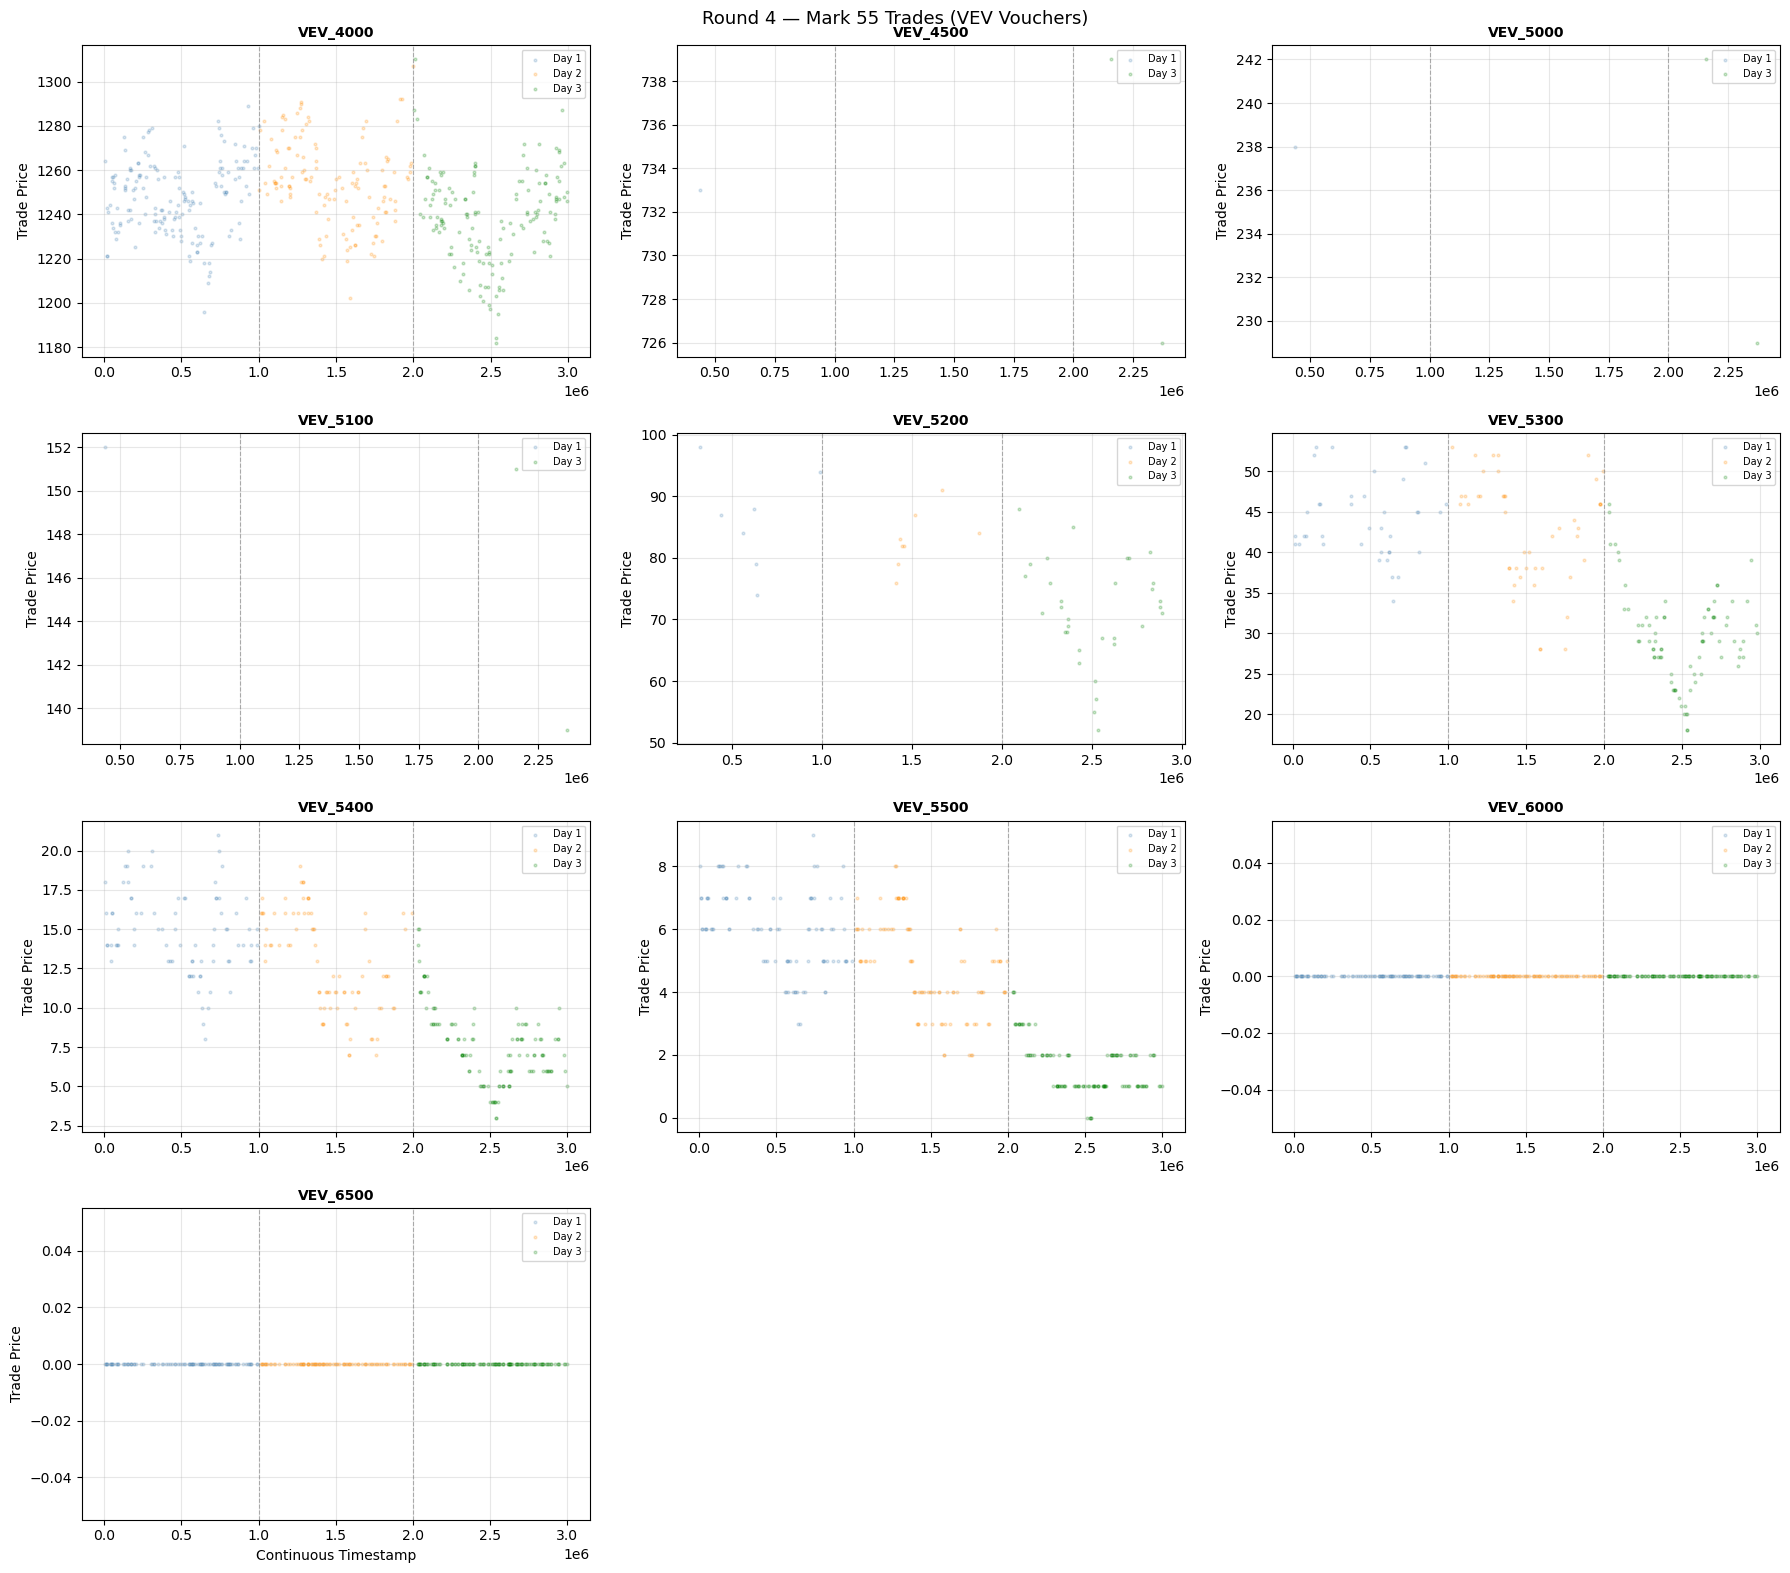

Saved: Mark_67_non_vouchers.png


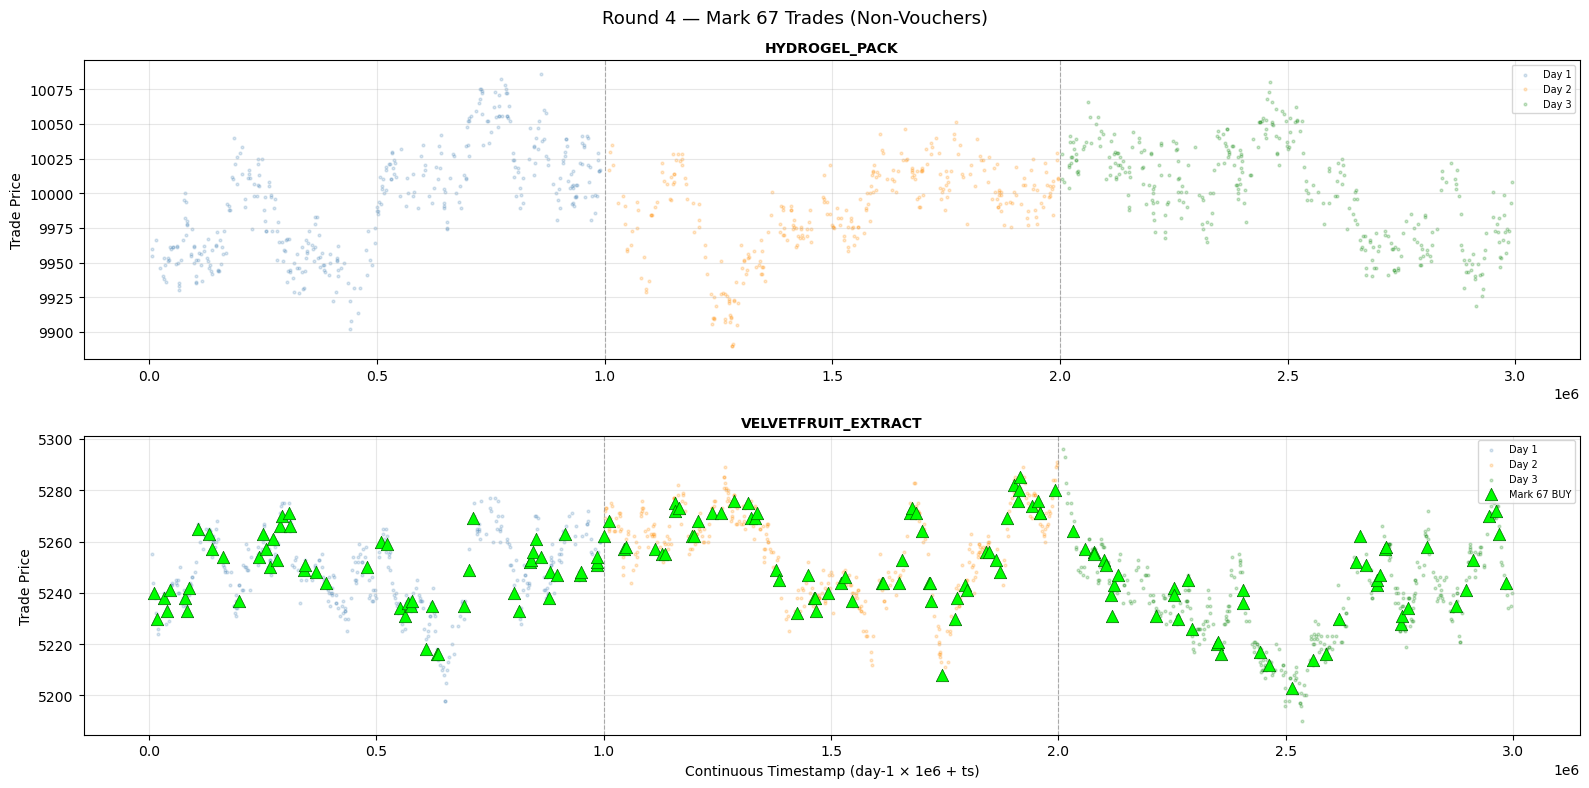

Saved: Mark_67_vouchers.png


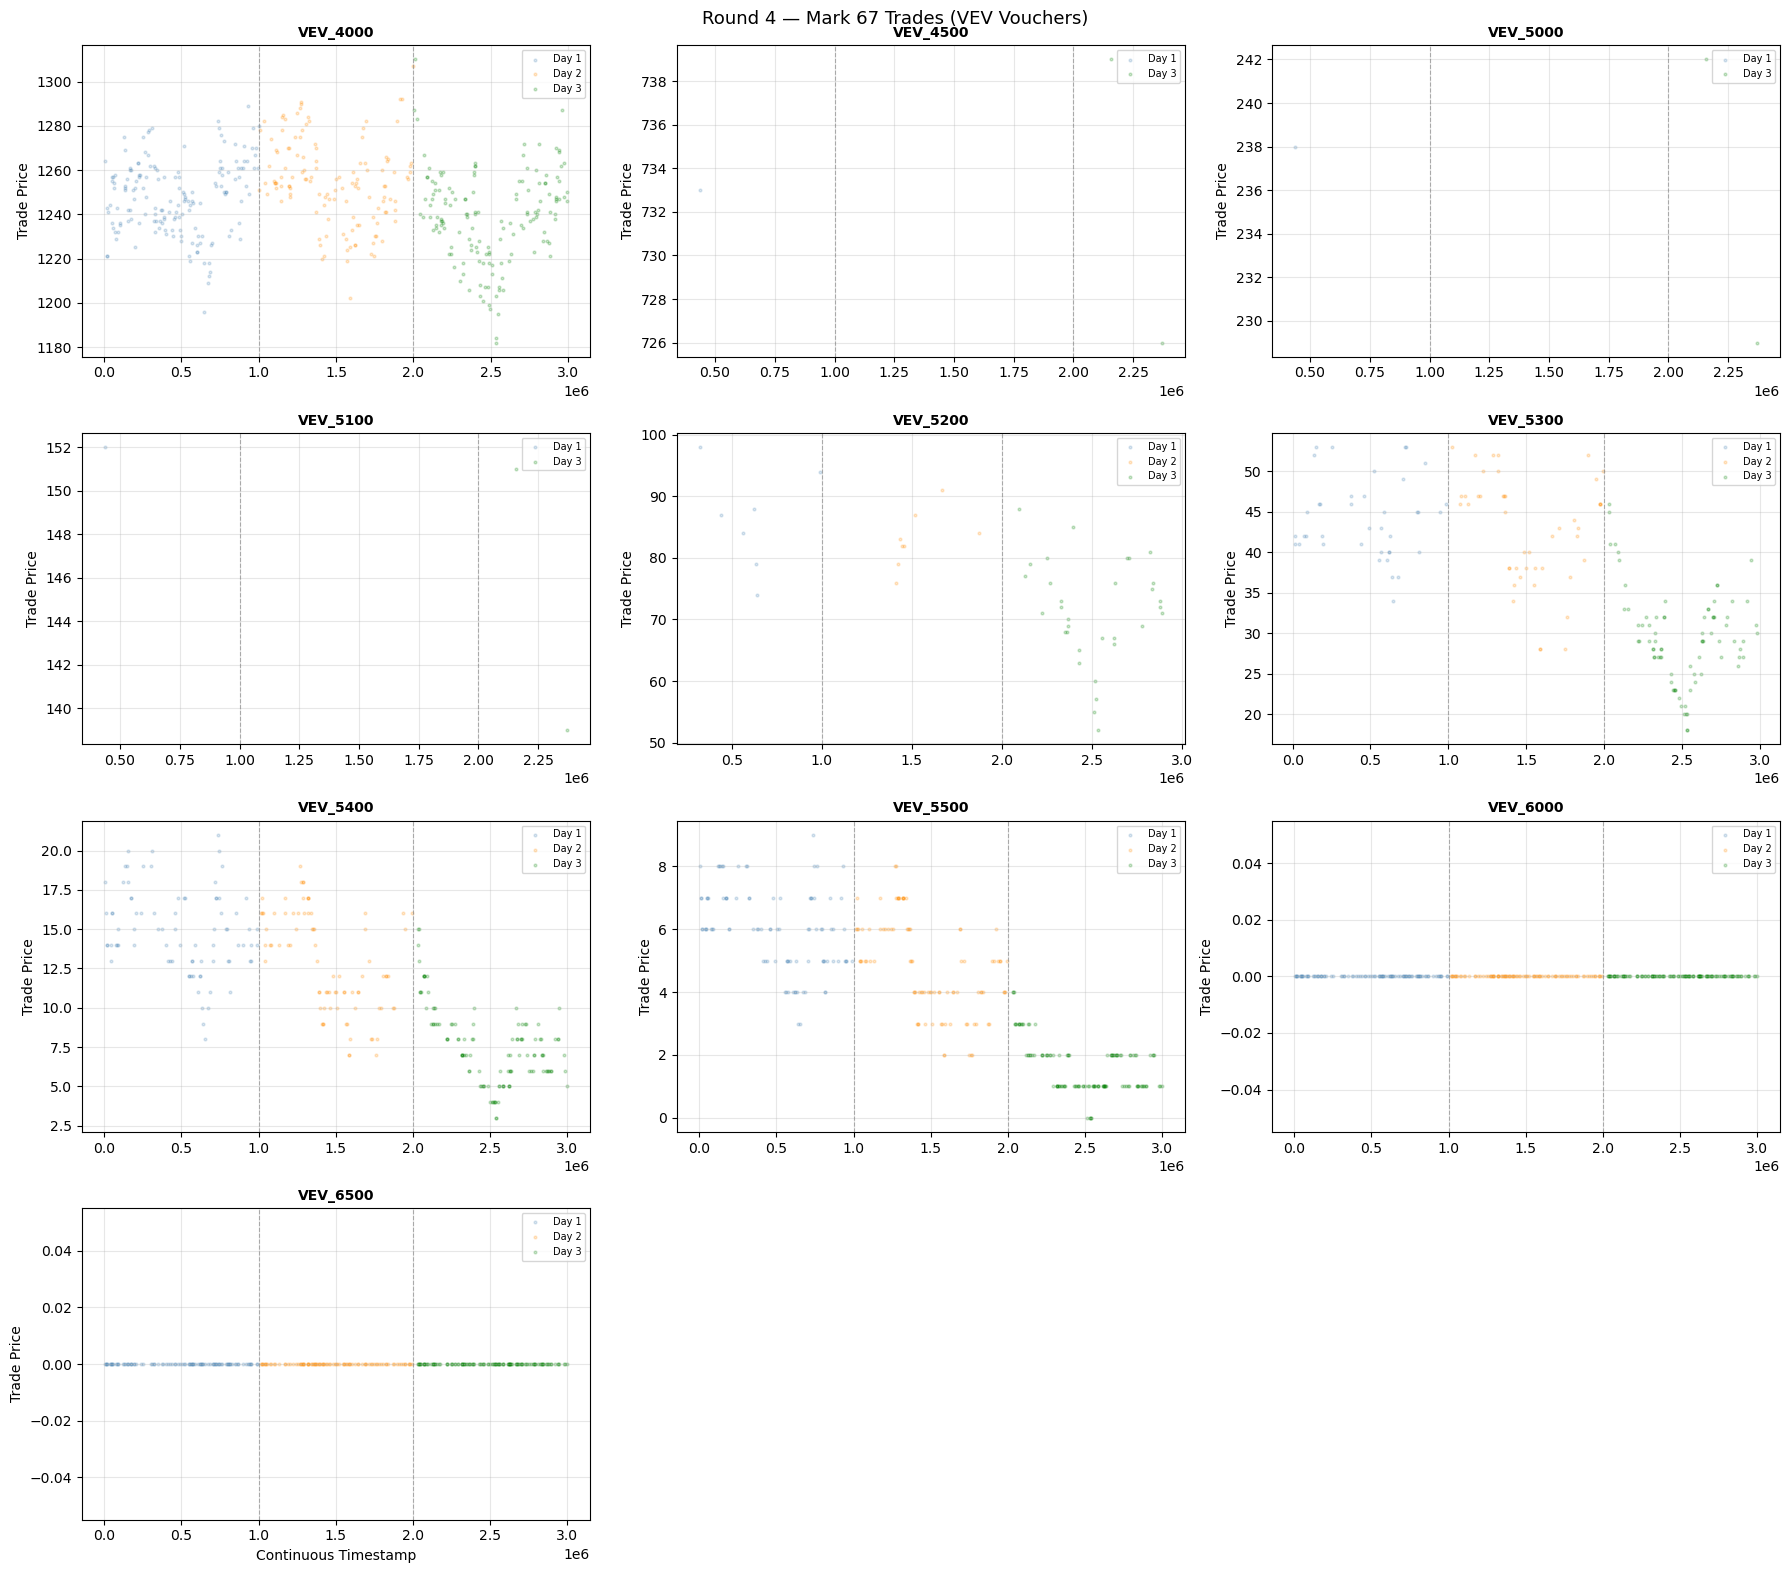

In [39]:
traders = ['01', '14', '22', '38', '49', '55', '67']
for t in traders:
    plot_trader(f'Mark {t}', save=True)

In [92]:
def voucher_profit(vev):
    v = trade_all[trade_all['symbol'] == f'VEV_{vev}'].rename(columns={'price': 'voucher_price'})
    v['voucher_price']+=vev
    extract_price = mid_price[mid_price['product'] == 'VELVETFRUIT_EXTRACT']
    v = v.merge(extract_price[['timestamp', 'product', 'mid_price']], left_on='t_cont', right_on='timestamp', how='inner')
    v['profit'] = v['voucher_price'] - v['mid_price']
    return v[['t_cont', 'voucher_price', 'profit']]

In [ ]:
voucher_profit(4000)


,t_cont,voucher_price,profit
0,5300,5264.0,10.5
1,16700,5221.0,-10.5
2,17300,5221.0,-10.5
3,17900,5243.0,10.0
4,25700,5241.0,9.5
...,...,...,...
437,2963200,5287.0,10.5
438,2972500,5248.0,-10.5
439,2973700,5263.0,10.5
440,2992600,5246.0,10.5
